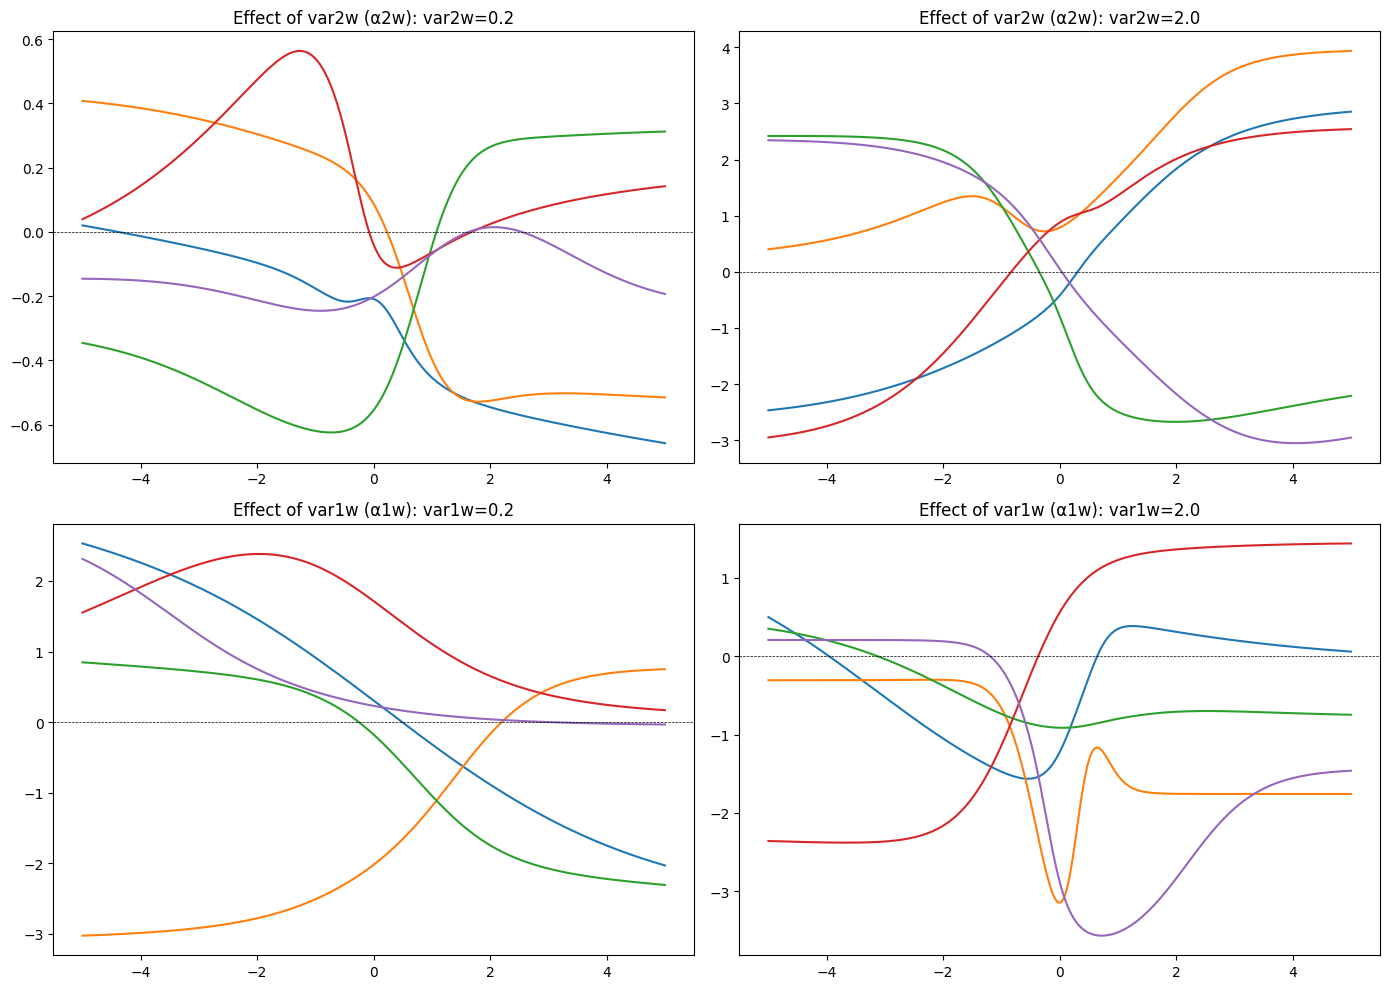

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Activation function (tanh for hidden layer)
def tanh(x):
    return np.tanh(x)

# Function to sample a network function given variances (inverse of α)
def sample_function(x, var1w=1.0, var1b=1.0, var2w=1.0, var2b=1.0, hidden_units=5):
    # First layer weights and biases
    W1 = np.random.normal(0, np.sqrt(var1w), size=(hidden_units, 1))
    b1 = np.random.normal(0, np.sqrt(var1b), size=(hidden_units, 1))
    
    # Hidden activations
    h = tanh(W1 @ x + b1)
    
    # Second layer weights and bias
    W2 = np.random.normal(0, np.sqrt(var2w), size=(1, hidden_units))
    b2 = np.random.normal(0, np.sqrt(var2b), size=(1, 1))
    
    # Output
    y = W2 @ h + b2
    return y.flatten()

# Input range
x = np.linspace(-5, 5, 200).reshape(1, -1)

# Plot effect of α2w (vertical scale)
plt.figure(figsize=(14, 10))

for i, var2w in enumerate([0.2, 2.0]):
    plt.subplot(2, 2, i+1)
    for _ in range(5):
        y = sample_function(x, var1w=1.0, var1b=1.0, var2w=var2w, var2b=0.1)
        plt.plot(x.flatten(), y)
    plt.title(f"Effect of var2w (α2w): var2w={var2w}")
    plt.axhline(0, color='k', linestyle='--', linewidth=0.5)

# Plot effect of α1w (horizontal scale)
for i, var1w in enumerate([0.2, 2.0]):
    plt.subplot(2, 2, i+3)
    for _ in range(5):
        y = sample_function(x, var1w=var1w, var1b=1.0, var2w=1.0, var2b=0.1)
        plt.plot(x.flatten(), y)
    plt.title(f"Effect of var1w (α1w): var1w={var1w}")
    plt.axhline(0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


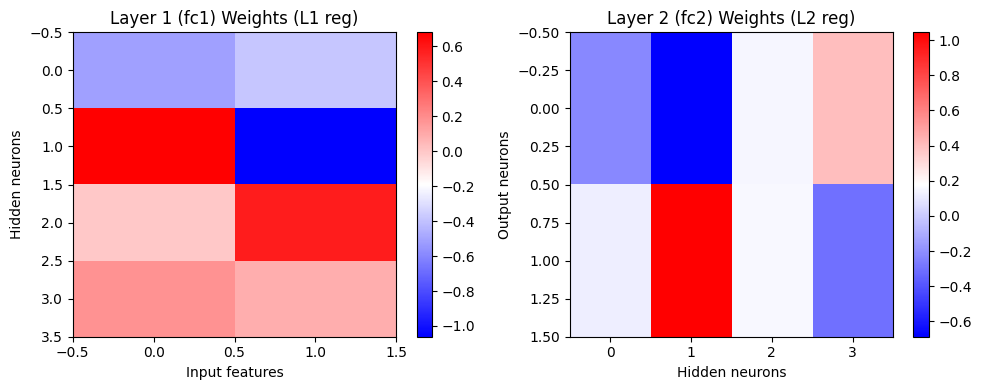

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---- Step 1: Dummy dataset ----
torch.manual_seed(0)
X = torch.randn(100, 2)
y = (X[:, 0] * 2 + X[:, 1] * -3 + 0.5 > 0).long()  # simple classification

# ---- Step 2: Define neural net ----
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 2)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

net = Net()

# ---- Step 3: Loss and optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1)

# ---- Step 4: Training loop with custom regularizers ----
for epoch in range(50):
    optimizer.zero_grad()
    outputs = net(X)
    loss = criterion(outputs, y)
    
    # Regularization terms: L1 for fc1, L2 for fc2
    l1_reg = torch.norm(net.fc1.weight, 1)
    l2_reg = torch.norm(net.fc2.weight, 2)
    
    loss = loss + 0.01 * l1_reg + 0.01 * l2_reg
    loss.backward()
    optimizer.step()

# ---- Step 5: Extract weights ----
fc1_weights = net.fc1.weight.detach().numpy()
fc2_weights = net.fc2.weight.detach().numpy()

# ---- Step 6: Plot weights ----
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(fc1_weights, cmap="bwr", aspect="auto")
axs[0].set_title("Layer 1 (fc1) Weights (L1 reg)")
axs[0].set_xlabel("Input features")
axs[0].set_ylabel("Hidden neurons")
axs[0].colorbar = plt.colorbar(axs[0].imshow(fc1_weights, cmap="bwr", aspect="auto"), ax=axs[0])

axs[1].imshow(fc2_weights, cmap="bwr", aspect="auto")
axs[1].set_title("Layer 2 (fc2) Weights (L2 reg)")
axs[1].set_xlabel("Hidden neurons")
axs[1].set_ylabel("Output neurons")
axs[1].colorbar = plt.colorbar(axs[1].imshow(fc2_weights, cmap="bwr", aspect="auto"), ax=axs[1])

plt.tight_layout()
plt.show()


Training finished. Final loss: 0.027600131928920746
Weights of first layer:
 [[ 0.16271925 -0.01097805]
 [ 0.71089387  0.21966943]
 [ 0.80191284  0.8479503 ]
 [-0.7777914  -0.82435375]]
Weights of second layer:
 [[-0.40171418  0.297293    1.0514511  -0.9162907 ]]


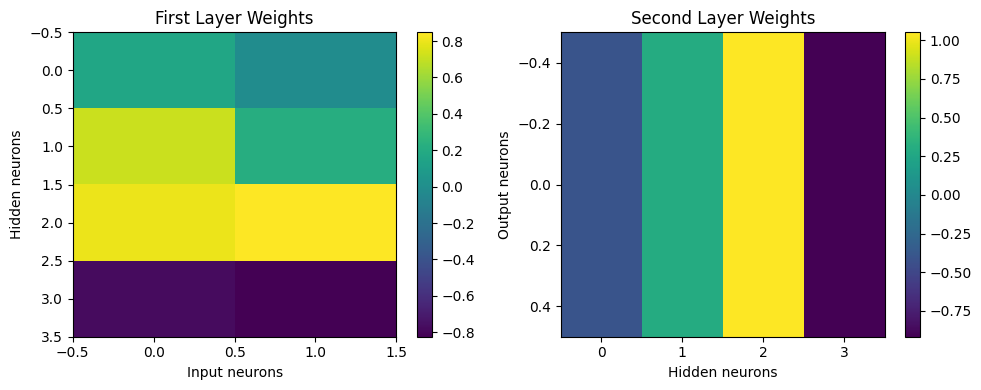

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ----- 1. Define a simple 2-layer NN -----
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(2, 4)  # input=2 -> hidden=4
        self.fc2 = nn.Linear(4, 1)  # hidden=4 -> output=1

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ----- 2. Dummy dataset (y = x1 + x2 + noise) -----
torch.manual_seed(0)
X = torch.randn(200, 2)
y = (X[:, 0] + X[:, 1] + 0.1*torch.randn(200)).unsqueeze(1)

# ----- 3. Train without regularization -----
model = SimpleNet()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

print("Training finished. Final loss:", loss.item())

# ----- 4. Extract weights -----
w1 = model.fc1.weight.data.numpy()
w2 = model.fc2.weight.data.numpy()

print("Weights of first layer:\n", w1)
print("Weights of second layer:\n", w2)

# ----- 5. Plot weights -----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("First Layer Weights")
plt.imshow(w1, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xlabel("Input neurons")
plt.ylabel("Hidden neurons")

plt.subplot(1,2,2)
plt.title("Second Layer Weights")
plt.imshow(w2, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xlabel("Hidden neurons")
plt.ylabel("Output neurons")

plt.tight_layout()
plt.show()


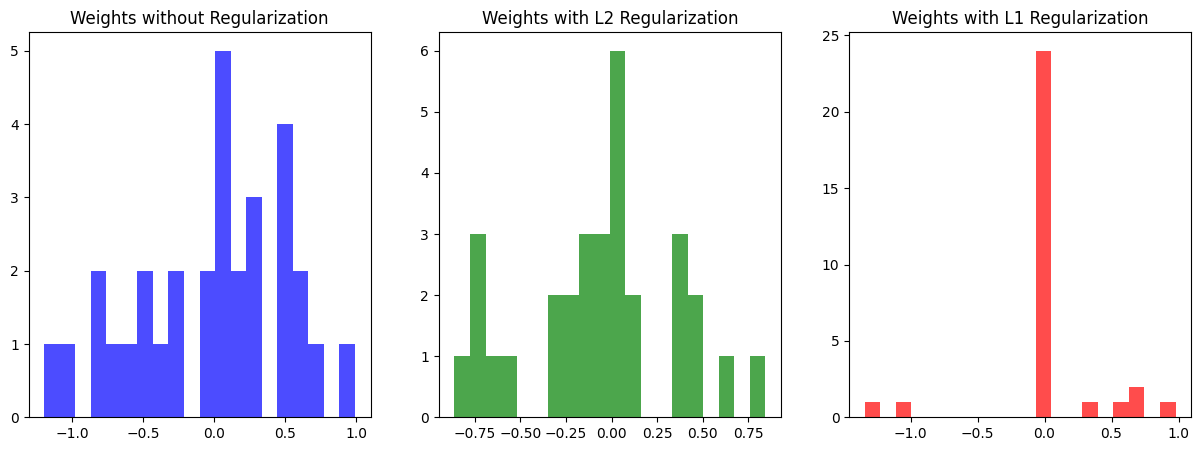

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Dummy dataset (simple regression: y = 2x + noise)
torch.manual_seed(0)
X = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1)
y = 2 * X + 0.3 * torch.randn(X.size())

# Simple Neural Network
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(1, 10)
        self.fc2 = nn.Linear(10, 1)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Training function
def train_model(regularizer=None, lambda_reg=0.01, epochs=200):
    model = SimpleNet()
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        
        # Add regularization
        if regularizer == "L2":
            l2_penalty = sum(torch.sum(param**2) for param in model.parameters())
            loss += lambda_reg * l2_penalty
        elif regularizer == "L1":
            l1_penalty = sum(torch.sum(torch.abs(param)) for param in model.parameters())
            loss += lambda_reg * l1_penalty

        loss.backward()
        optimizer.step()
    
    return model

# Train models
model_no_reg = train_model(regularizer=None)
model_l2 = train_model(regularizer="L2", lambda_reg=0.05)
model_l1 = train_model(regularizer="L1", lambda_reg=0.05)

# Collect weights
weights_no_reg = torch.cat([p.view(-1) for p in model_no_reg.parameters()])
weights_l2 = torch.cat([p.view(-1) for p in model_l2.parameters()])
weights_l1 = torch.cat([p.view(-1) for p in model_l1.parameters()])

# Plot histograms
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(weights_no_reg.detach().numpy(), bins=20, color='blue', alpha=0.7)
plt.title("Weights without Regularization")

plt.subplot(1,3,2)
plt.hist(weights_l2.detach().numpy(), bins=20, color='green', alpha=0.7)
plt.title("Weights with L2 Regularization")

plt.subplot(1,3,3)
plt.hist(weights_l1.detach().numpy(), bins=20, color='red', alpha=0.7)
plt.title("Weights with L1 Regularization")

plt.show()


### L2 → restricts direction & magnitude smoothly (like shrinking along x/y axes → "circle-like").

### L1 → restricts individual weights sharply (like snapping weights to 0 → “diamond corners”).



### L2 = circles → weights shrink but don’t vanish.

### L1 = diamonds → optimizer hits corners → some weights forced to 0.

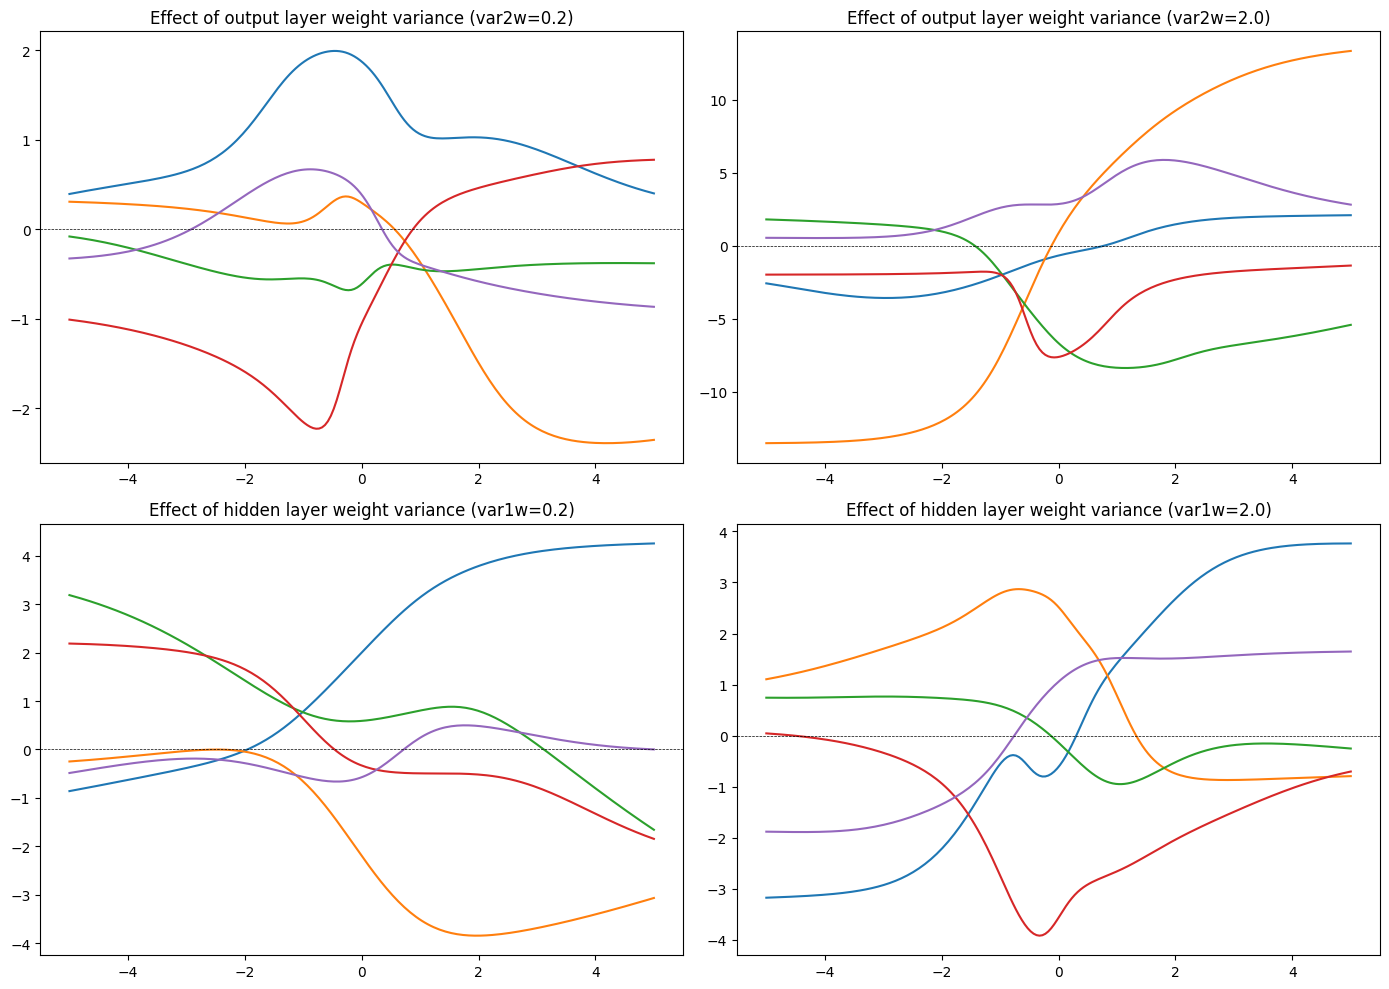

In [6]:
# Illustration: Effect of prior hyperparameters on weights/biases in a 2-layer tanh network
import numpy as np
import matplotlib.pyplot as plt

def tanh(x):
    return np.tanh(x)

# Function to sample a network function given variances (prior hyperparameters)
def sample_function(x, var1w=1.0, var1b=1.0, var2w=1.0, var2b=1.0, hidden_units=12):
    W1 = np.random.normal(0, np.sqrt(var1w), size=(hidden_units, 1))
    b1 = np.random.normal(0, np.sqrt(var1b), size=(hidden_units, 1))
    h = tanh(W1 @ x + b1)
    W2 = np.random.normal(0, np.sqrt(var2w), size=(1, hidden_units))
    b2 = np.random.normal(0, np.sqrt(var2b), size=(1, 1))
    y = W2 @ h + b2
    return y.flatten()

x = np.linspace(-5, 5, 200).reshape(1, -1)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Vary output layer weight variance (vertical scale)
for i, var2w in enumerate([0.2, 2.0]):
    ax = axs[0, i]
    for _ in range(5):
        y = sample_function(x, var1w=1.0, var1b=1.0, var2w=var2w, var2b=0.1)
        ax.plot(x.flatten(), y)
    ax.set_title(f"Effect of output layer weight variance (var2w={var2w})")
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)

# Vary hidden layer weight variance (horizontal scale)
for i, var1w in enumerate([0.2, 2.0]):
    ax = axs[1, i]
    for _ in range(5):
        y = sample_function(x, var1w=var1w, var1b=1.0, var2w=1.0, var2b=0.1)
        ax.plot(x.flatten(), y)
    ax.set_title(f"Effect of hidden layer weight variance (var1w={var1w})")
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

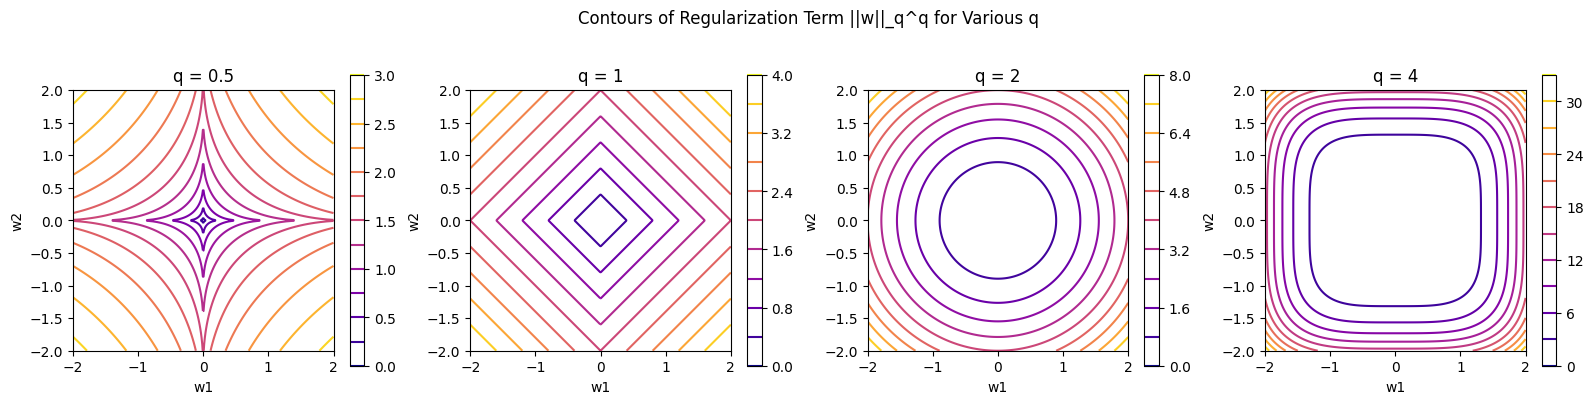

In [7]:
# Contours of the regularization term ||w||_q^q for various q
import numpy as np
import matplotlib.pyplot as plt

w1 = np.linspace(-2, 2, 400)
w2 = np.linspace(-2, 2, 400)
W1, W2 = np.meshgrid(w1, w2)

qs = [0.5, 1, 2, 4]
fig, axs = plt.subplots(1, len(qs), figsize=(16, 4))

for i, q in enumerate(qs):
    reg = np.abs(W1)**q + np.abs(W2)**q
    ax = axs[i]
    cs = ax.contour(W1, W2, reg, levels=10, cmap='plasma')
    ax.set_title(f"q = {q}")
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.set_aspect('equal')
    fig.colorbar(cs, ax=ax)

plt.suptitle("Contours of Regularization Term ||w||_q^q for Various q")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

w1 weights : [-0.50183952  1.80285723  0.92797577  0.39463394 -1.37592544 -1.37602192
 -1.76766555  1.46470458  0.40446005  0.83229031]
w2 weights : [-1.91766202  1.87963941  1.32977056 -1.15064356 -1.27270013 -1.26638196
 -0.78303103  0.09902573 -0.27221993 -0.83508344]


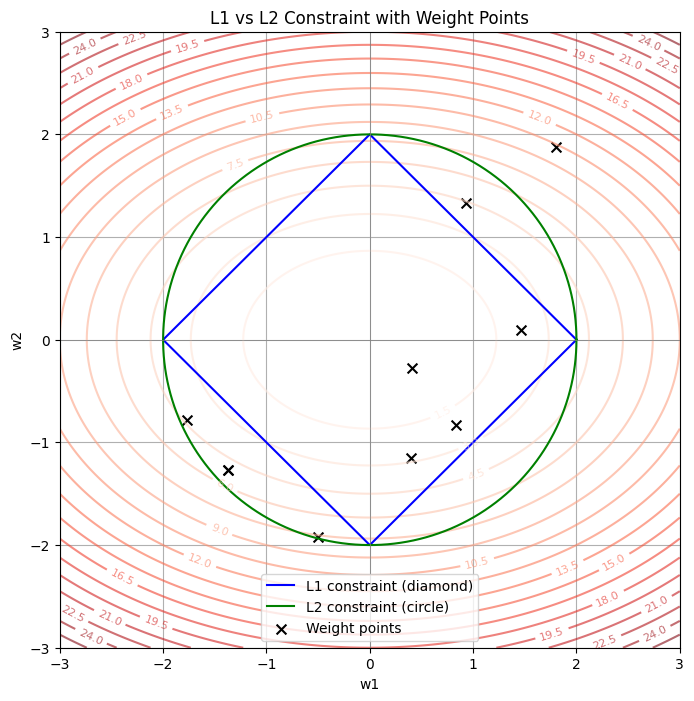

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 10 random weights for w1 and w2
np.random.seed(42)
w1 = np.random.uniform(-2, 2, 10)
w2 = np.random.uniform(-2, 2, 10)

# Constraint values for L1 and L2
c = 2

# Create grid for contours (error function approximation)
W1, W2 = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = W1**2 + 2*W2**2  # a simple quadratic error function

print(f"w1 weights : {w1}")
print(f"w2 weights : {w2}")

# Plot
plt.figure(figsize=(8, 8))

# Contours of error function
contours = plt.contour(W1, W2, Z, levels=20, cmap="Reds", alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

# L1 (diamond) region
l1_boundary = plt.plot([c, 0, -c, 0, c], [0, c, 0, -c, 0], 'b-', label="L1 constraint (diamond)")

# L2 (circle) region
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(c*np.cos(theta), c*np.sin(theta), 'g-', label="L2 constraint (circle)")

# Plot weights
plt.scatter(w1, w2, c='black', s=50, marker='x', label="Weight points")

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("L1 vs L2 Constraint with Weight Points")
plt.legend()
plt.grid(True)
plt.show()


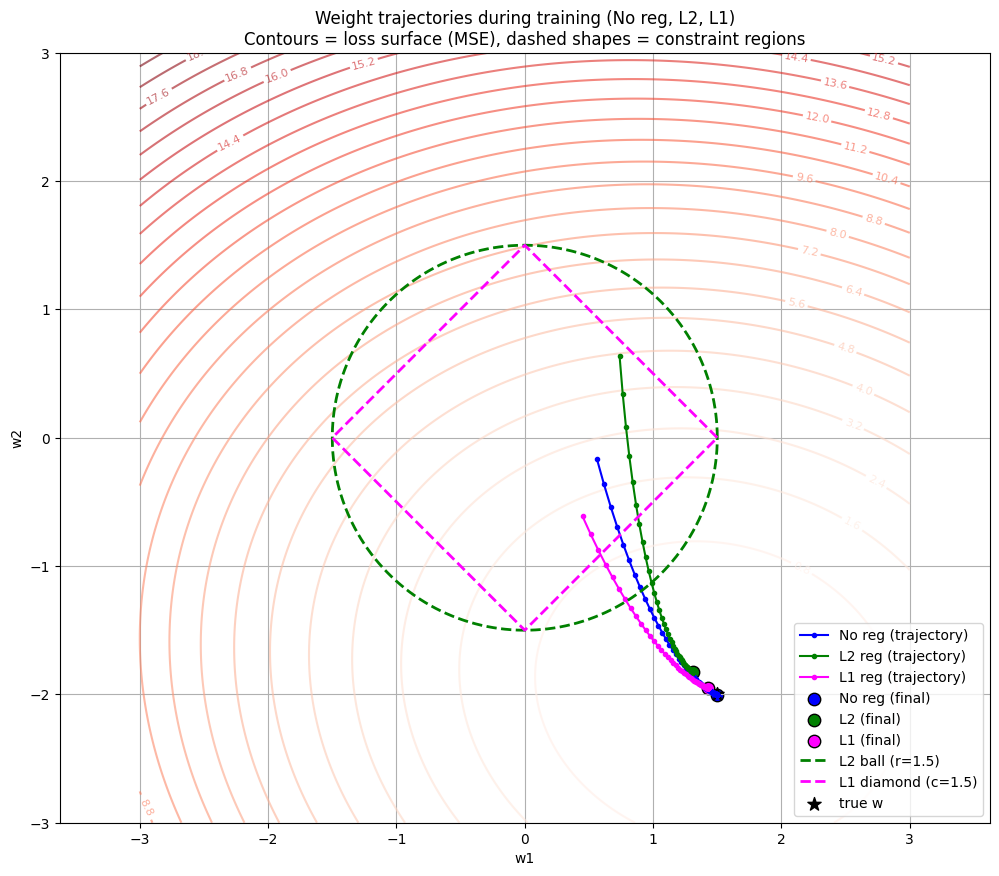

In [10]:
# save as visualize_l1_l2.py and run: python visualize_l1_l2.py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# --- Synthetic dataset (2 features) ---
N = 200
X = torch.randn(N, 2)
# True weights (for target) so problem is solvable with 2 weights
w_true = torch.tensor([1.5, -2.0])
y = (X @ w_true).unsqueeze(1) + 0.1 * torch.randn(N, 1)

# --- Tiny model with EXACTLY two weights (no bias) ---
class TinyLinear(nn.Module):
    def __init__(self):
        super().__init__()
        # weight shape: (1,2) -> flattened to 2 params w1,w2
        self.w = nn.Parameter(torch.randn(1,2) * 0.5)  # initialize small

    def forward(self, x):
        return x @ self.w.t()  # result shape (N,1)

def train_and_record(regularizer=None, lambda_reg=0.01, lr=0.05, epochs=200):
    model = TinyLinear()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    # record weight vectors each epoch
    traj = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        # add regularization to loss (applied to model.w)
        if regularizer == "L2":
            loss = loss + lambda_reg * torch.sum(model.w**2)
        elif regularizer == "L1":
            loss = loss + lambda_reg * torch.sum(torch.abs(model.w))
        loss.backward()
        optimizer.step()
        # store current (w1,w2) as numpy
        w_np = model.w.detach().cpu().numpy().reshape(-1)
        traj.append(w_np.copy())
    traj = np.array(traj)  # epochs x 2
    return traj, model

# --- Train three variants ---
traj_none, model_none = train_and_record(regularizer=None, lambda_reg=0.0, lr=0.05, epochs=400)
traj_l2, model_l2 = train_and_record(regularizer="L2", lambda_reg=0.1, lr=0.05, epochs=400)
traj_l1, model_l1 = train_and_record(regularizer="L1", lambda_reg=0.1, lr=0.05, epochs=400)

# --- Build loss-surface contours (analytical quadratic approx) ---
w1_vals = np.linspace(-3.0, 3.0, 300)
w2_vals = np.linspace(-3.0, 3.0, 300)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

# compute MSE loss at each (w1,w2) for our dataset: L(w) = 0.5/N * sum((Xw - y)^2)
# we'll compute per-grid efficiently using numpy
X_np = X.numpy()
y_np = y.numpy().reshape(-1)
# compute predictions for each grid point via broadcasting
# shape: (grid_points, N)
grid_w = np.stack([W1.ravel(), W2.ravel()]).T  # (G,2)
preds = X_np @ grid_w.T  # (N, G)
res = preds - y_np[:,None]  # (N, G)
mse = 0.5 * np.mean(res**2, axis=0)  # (G,)
MSE_grid = mse.reshape(W1.shape)

# --- Plotting ---
plt.figure(figsize=(12,10))

# Contour plot of the loss surface
levels = np.logspace(np.log10(MSE_grid.min()+1e-8), np.log10(MSE_grid.max()), 30)
ax = plt.gca()
cs = ax.contour(W1, W2, MSE_grid, levels=30, cmap='Reds', alpha=0.6)
plt.clabel(cs, inline=1, fontsize=8)

# plot trajectories
plt.plot(traj_none[:,0], traj_none[:,1], '-o', color='blue', markersize=3, label='No reg (trajectory)')
plt.plot(traj_l2[:,0], traj_l2[:,1], '-o', color='green', markersize=3, label='L2 reg (trajectory)')
plt.plot(traj_l1[:,0], traj_l1[:,1], '-o', color='magenta', markersize=3, label='L1 reg (trajectory)')

# mark final points
plt.scatter(traj_none[-1,0], traj_none[-1,1], color='blue', s=80, edgecolor='k', label='No reg (final)')
plt.scatter(traj_l2[-1,0], traj_l2[-1,1], color='green', s=80, edgecolor='k', label='L2 (final)')
plt.scatter(traj_l1[-1,0], traj_l1[-1,1], color='magenta', s=80, edgecolor='k', label='L1 (final)')

# draw L2 circle (norm radius = r)
c = 1.5  # choose radius for illustration
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(c*np.cos(theta), c*np.sin(theta), color='green', linestyle='--', linewidth=2, label=f'L2 ball (r={c})')

# draw L1 diamond (|w1| + |w2| = c)
c1 = 1.5
diamond_x = np.array([ c1, 0, -c1,  0,  c1 ])
diamond_y = np.array([ 0,  c1,  0, -c1,   0 ])
plt.plot(diamond_x, diamond_y, color='magenta', linestyle='--', linewidth=2, label=f'L1 diamond (c={c1})')

# true weight marker
plt.scatter(w_true[0].item(), w_true[1].item(), color='black', s=100, marker='*', label='true w')

plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Weight trajectories during training (No reg, L2, L1)\nContours = loss surface (MSE), dashed shapes = constraint regions')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


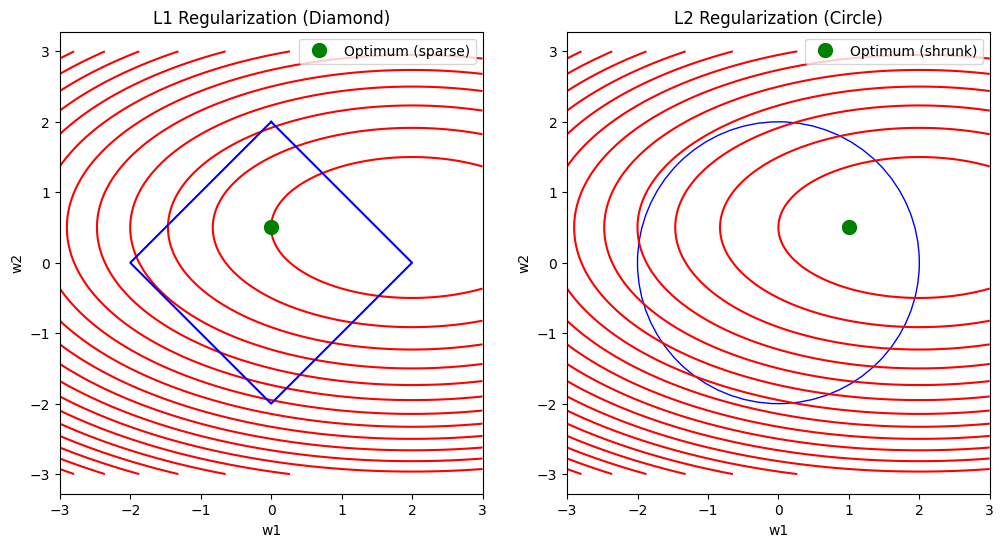

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Define the unregularized error contours (ellipses)
w1 = np.linspace(-3, 3, 400)
w2 = np.linspace(-3, 3, 400)
W1, W2 = np.meshgrid(w1, w2)

# Example unregularized error function (elliptical quadratic form)
error = (W1 - 2)**2 + (2*W2 - 1)**2  

# Define constraint regions
l1_constraint = np.abs(W1) + np.abs(W2) <= 2  # diamond (L1)
l2_constraint = W1**2 + W2**2 <= 2**2        # circle (L2)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# ---- L1 Regularizer (diamond) ----
ax[0].contour(W1, W2, error, levels=20, colors='red')  # error contours
# diamond boundary
ax[0].plot([0, 2, 0, -2, 0], [2, 0, -2, 0, 2], 'b-')
ax[0].set_title("L1 Regularization (Diamond)")
ax[0].set_xlabel("w1")
ax[0].set_ylabel("w2")
ax[0].axis("equal")

# Mark the solution on axis (sparse: w1=0)
ax[0].plot(0, 0.5, 'go', markersize=10, label="Optimum (sparse)")
ax[0].legend()

# ---- L2 Regularizer (circle) ----
ax[1].contour(W1, W2, error, levels=20, colors='red')  # error contours
circle = plt.Circle((0, 0), 2, color='b', fill=False)
ax[1].add_patch(circle)
ax[1].set_title("L2 Regularization (Circle)")
ax[1].set_xlabel("w1")
ax[1].set_ylabel("w2")
ax[1].axis("equal")

# Mark the solution inside circle (both shrunk)
ax[1].plot(1.0, 0.5, 'go', markersize=10, label="Optimum (shrunk)")
ax[1].legend()

plt.show()


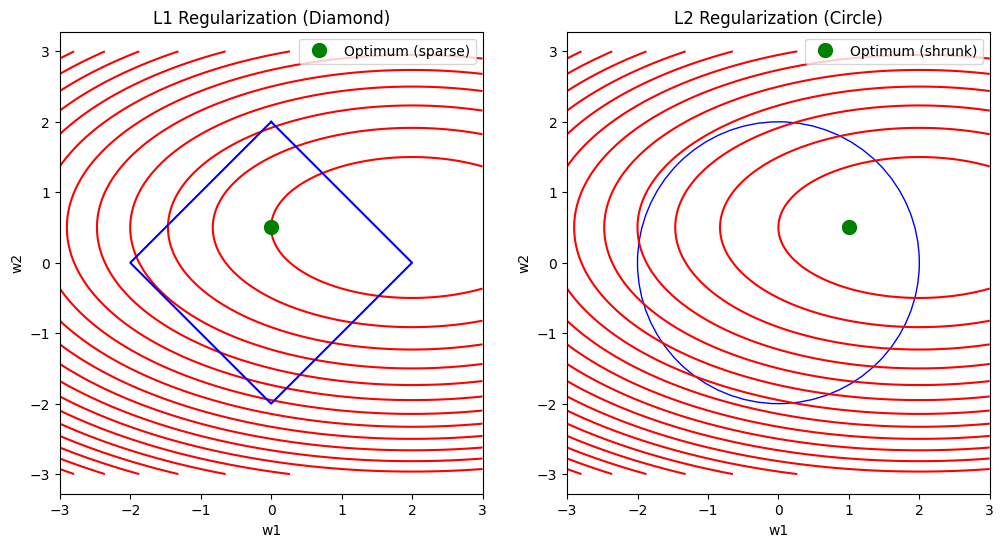

In [12]:
# Plot contours of the unregularized error function and constraint regions for L1 (lasso) and L2 (quadratic) regularizers
import numpy as np
import matplotlib.pyplot as plt

# Define the unregularized error contours (ellipses)
w1 = np.linspace(-3, 3, 400)
w2 = np.linspace(-3, 3, 400)
W1, W2 = np.meshgrid(w1, w2)

# Example unregularized error function (elliptical quadratic form)
error = (W1 - 2)**2 + (2*W2 - 1)**2

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# ---- L1 Regularizer (diamond) ----
ax[0].contour(W1, W2, error, levels=20, colors='red')  # error contours
# diamond boundary
ax[0].plot([0, 2, 0, -2, 0], [2, 0, -2, 0, 2], 'b-')
ax[0].set_title("L1 Regularization (Diamond)")
ax[0].set_xlabel("w1")
ax[0].set_ylabel("w2")
ax[0].axis("equal")
# Mark the solution on axis (sparse: w1=0)
ax[0].plot(0, 0.5, 'go', markersize=10, label="Optimum (sparse)")
ax[0].legend()

# ---- L2 Regularizer (circle) ----
ax[1].contour(W1, W2, error, levels=20, colors='red')  # error contours
circle = plt.Circle((0, 0), 2, color='b', fill=False)
ax[1].add_patch(circle)
ax[1].set_title("L2 Regularization (Circle)")
ax[1].set_xlabel("w1")
ax[1].set_ylabel("w2")
ax[1].axis("equal")
# Mark the solution inside circle (both shrunk)
ax[1].plot(1.0, 0.5, 'go', markersize=10, label="Optimum (shrunk)")
ax[1].legend()

plt.show()

## Detailed Explanation: Error Contours and Regularization Constraint Regions

This plot visualizes how different regularization methods (L1 and L2) affect the solution to a regression problem in weight space:

- **Red Contours:** These represent the unregularized error function (e.g., mean squared error) as a function of two weights, $w_1$ and $w_2$. The contours are ellipses centered at the minimum of the error function, showing regions of equal error.

- **Left Panel (L1 Regularization - Diamond):**
    - The blue diamond shows the constraint region for the L1 regularizer (lasso), defined by $|w_1| + |w_2| \leq c$.
    - L1 regularization encourages sparsity, meaning it prefers solutions where some weights are exactly zero. In this plot, the optimum (green dot) lies on the $w_1=0$ axis, demonstrating a sparse solution: one weight is forced to zero while the other is nonzero.
    - The intersection of the error contours and the diamond boundary determines the optimal weights under the L1 constraint.

- **Right Panel (L2 Regularization - Circle):**
    - The blue circle shows the constraint region for the L2 regularizer (ridge), defined by $w_1^2 + w_2^2 \leq c^2$.
    - L2 regularization shrinks all weights smoothly toward zero but does not force them to be exactly zero. The optimum (green dot) is inside the circle, with both weights reduced in magnitude compared to the unconstrained minimum.
    - The intersection of the error contours and the circle boundary determines the optimal weights under the L2 constraint.

**Summary:**
- L1 regularization (lasso) leads to sparse solutions, often setting some weights exactly to zero (feature selection).
- L2 regularization (ridge) shrinks all weights but keeps them nonzero, leading to smoother solutions.
- The geometric interpretation helps understand why lasso is good for sparsity and ridge for smooth shrinkage.

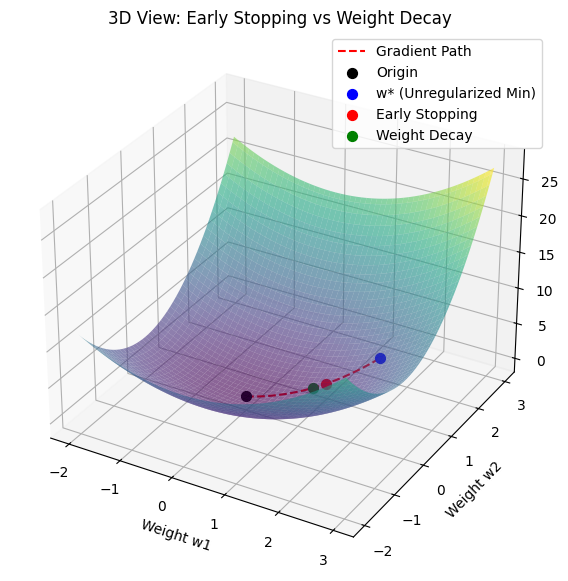

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid
x = np.linspace(-2, 3, 100)
y = np.linspace(-2, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + 2*Y**2  # quadratic surface

# Define key points
origin = np.array([0, 0])
w_star = np.array([2, 1])
early_stopping = np.array([1.2, 0.6])
weight_decay = np.array([1.0, 0.5])

# Compute heights (errors) at each point
z_origin = origin[0]**2 + 2*origin[1]**2
z_star = w_star[0]**2 + 2*w_star[1]**2
z_early = early_stopping[0]**2 + 2*early_stopping[1]**2
z_decay = weight_decay[0]**2 + 2*weight_decay[1]**2

# Path along gradient descent
t = np.linspace(0, 1, 100)
path = np.outer(1 - t, origin) + np.outer(t, w_star)
z_path = path[:, 0]**2 + 2*path[:, 1]**2

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis', edgecolor='none')

# Plot path and points
ax.plot(path[:, 0], path[:, 1], z_path, 'r--', label='Gradient Path')
ax.scatter(*origin, z_origin, color='k', s=50, label='Origin')
ax.scatter(*w_star, z_star, color='b', s=50, label='w* (Unregularized Min)')
ax.scatter(*early_stopping, z_early, color='r', s=50, label='Early Stopping')
ax.scatter(*weight_decay, z_decay, color='g', s=50, label='Weight Decay')

# Labels
ax.set_title('3D View: Early Stopping vs Weight Decay')
ax.set_xlabel('Weight w1')
ax.set_ylabel('Weight w2')
ax.set_zlabel('Error')
ax.legend()

plt.show()


## Difference Between Normal Weights and Soft Weight Sharing (with Plot Reference)

**Normal Weights:**
- In standard neural networks, each weight parameter is learned independently, with its own value determined by the optimization process.
- Regularization (like L1 or L2) can shrink or sparsify weights, but does not explicitly encourage any relationship between different weights.
- In plots, normal weights are distributed according to the loss surface and regularization constraints, with no enforced grouping or clustering.

**Soft Weight Sharing:**
- Soft weight sharing is a regularization technique where weights are encouraged (but not forced) to cluster around a small number of values.
- This is typically achieved by introducing a prior (often a mixture of Gaussians) over the weights, so that the optimization prefers weights to group into clusters (e.g., some weights close to zero, others close to a shared value).
- In plots, soft weight sharing would show weights forming visible clusters or groups, rather than being spread out independently. The histogram of weights would have peaks at the shared values, and the constraint region may reflect these clusters.

**Visual Difference in Plots:**
- **Normal weights:** Histogram or scatter plot shows a spread of values, possibly shrunk or sparse, but no clear grouping.
- **Soft weight sharing:** Histogram or scatter plot shows distinct peaks or clusters, indicating that many weights have similar values due to the sharing prior.

**Summary:**
- Normal weights: Each weight is independent, shaped only by loss and regularization.
- Soft weight sharing: Weights are softly encouraged to group, leading to clusters in their values and potentially improved generalization or compression.

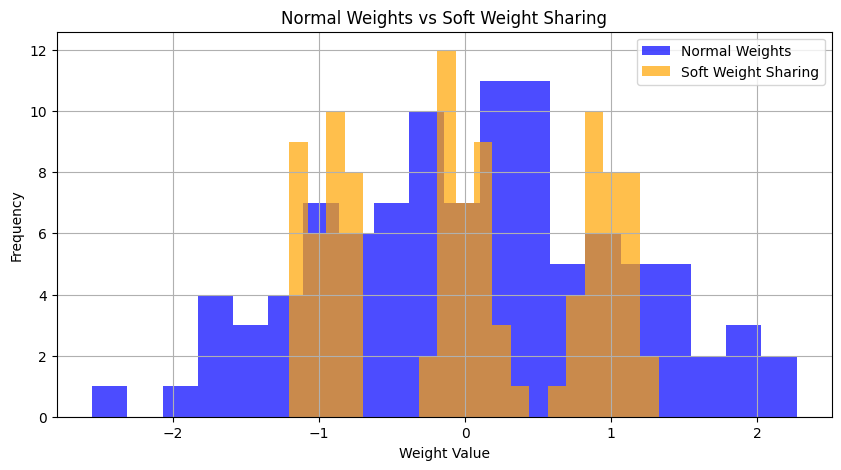

In [15]:
# Plot: Difference between normal weights and soft weight sharing
import numpy as np
import matplotlib.pyplot as plt

# Simulate normal weights (spread out, e.g. from standard training)
np.random.seed(0)
normal_weights = np.random.normal(loc=0, scale=1, size=100)

# Simulate soft weight sharing (weights cluster around -1, 0, and 1)
clusters = [-1, 0, 1]
soft_weights = np.concatenate([
    np.random.normal(loc=c, scale=0.15, size=33) for c in clusters
])
soft_weights = np.append(soft_weights, np.random.normal(loc=0, scale=0.15, size=1))  # make 100 total

plt.figure(figsize=(10,5))
plt.hist(normal_weights, bins=20, alpha=0.7, label='Normal Weights', color='blue')
plt.hist(soft_weights, bins=20, alpha=0.7, label='Soft Weight Sharing', color='orange')
plt.title('Normal Weights vs Soft Weight Sharing')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

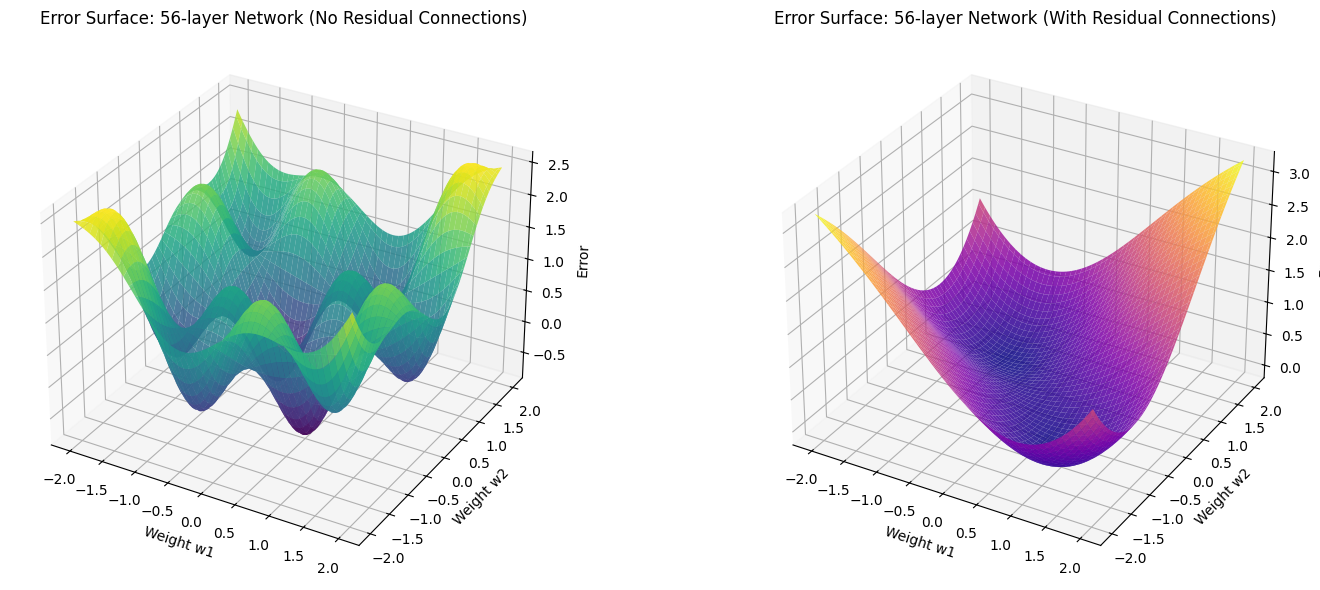

In [16]:
# Visualization: Error surface for a 56-layer network vs. with residual connections
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of weight values
w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1, w2)

# (a) Deep network without residual connections: Rugged error surface
# Simulate with a highly non-convex function (many local minima)
error_no_res = np.sin(3*W1) * np.sin(3*W2) + 0.3*(W1**2 + W2**2)

# (b) Deep network with residual connections: Smoother error surface
# Simulate with a smoother function (fewer local minima)
error_res = np.sin(W1) * np.sin(W2) + 0.3*(W1**2 + W2**2)

fig = plt.figure(figsize=(16, 6))

# Plot (a): Without residual connections
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(W1, W2, error_no_res, cmap='viridis', alpha=0.85, edgecolor='none')
ax1.set_title('Error Surface: 56-layer Network (No Residual Connections)')
ax1.set_xlabel('Weight w1')
ax1.set_ylabel('Weight w2')
ax1.set_zlabel('Error')

# Plot (b): With residual connections
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, error_res, cmap='plasma', alpha=0.85, edgecolor='none')
ax2.set_title('Error Surface: 56-layer Network (With Residual Connections)')
ax2.set_xlabel('Weight w1')
ax2.set_ylabel('Weight w2')
ax2.set_zlabel('Error')

plt.tight_layout()
plt.show()